# Predicción de Fallo Cardíaco - Análisis Exploratorio de Datos (EDA)

 El objetivo principal es analizar un conjunto de datos clínicos para identificar patrones y factores de riesgo que contribuyen al fallo cardíaco. A través de este análisis, prepararemos los datos para entrenar un modelo de clasificación capaz de predecir la salud cardiovascular de nuevos pacientes.
 ### Analista:
 Gema

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Esto es para que los gráficos tengan un estilo más elegante por defecto
sns.set(style="whitegrid")

In [2]:
df_raw = pd.read_csv("../data/heart.csv")

# Creamos copia para trabajar
df = df_raw.copy()

# A partir de aquí, todos los cambios (como los del colesterol) se hacen en 'df'

In [3]:
 df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [4]:
df.shape

(918, 12)

In [5]:
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB
None


## Tipo de Dato
* Age,Edad,Numérico

* Sex,"Sexo (M: Hombre, F: Mujer)",Categórico

* ChestPainType,Tipo de Dolor Torácico,Categórico

* RestingBP,Presión Arterial en Reposo,Numérico

* Cholesterol,Colesterol,Numérico

* FastingBS,Azúcar en Sangre en Ayunas (>120 mg/dl),Binario (0 o 1)

* RestingECG,Electrocardiograma en Reposo,Categórico

* MaxHR,Frecuencia Cardíaca Máxima,Numérico

* ExerciseAngina,Angina Inducida por Ejercicio,Categórico

* Oldpeak,Depresión del ST (por ejercicio),Decimal

* ST_Slope,Pendiente del Segmento ST,Categórico

* HeartDisease,Enfermedad Cardíaca (Objetivo),Binario (0 o 1)

In [6]:
print("\n--- ¿HAY HUECOS VACÍOS? ---")
print(df.isnull().sum())

# 3. Ver si hay filas repetidas
print(f"\nFilas duplicadas: {df.duplicated().sum()}")


--- ¿HAY HUECOS VACÍOS? ---
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Filas duplicadas: 0


Miramos si hay datos que en las columnas tengan 0 que sean relevantes para nuestro  analisis para porque algunas columnas con datos 0 en colesterol y Presion arterial que 0 son datos imposibles o sea seria nulos tambien.

In [7]:
(df == 0).sum()

Age                 0
Sex                 0
ChestPainType       0
RestingBP           1
Cholesterol       172
FastingBS         704
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak           368
ST_Slope            0
HeartDisease      410
dtype: int64

Miramos para ver la

In [8]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Calculamos la mediana de colesterol de todos los valores que sean mayor que 0

In [9]:
df[df["Cholesterol"] >0]["Cholesterol"].mean()

np.float64(244.6353887399464)

Calculamos la media(50%) de colesterol todos los valores que sean mayor que 0

In [10]:
mediana_real = df[df["Cholesterol"] > 0]["Cholesterol"].median()
print(f"La mediana real (sin ceros) es: {mediana_real}")

La mediana real (sin ceros) es: 237.0


Sustituimos los 0 de la columna Colesterol y Presion Arterial por la media de esos valores a todos los pacientes que tienen 0

In [11]:
# Sustituimos los ceros por las medianas reales
df['Cholesterol'] = df['Cholesterol'].replace(0, 237)
df['RestingBP'] = df['RestingBP'].replace(0, 130)

Miramos si nos han quedado columnas con 0 que sean relevantes para nuestro analisis

In [12]:
(df==0).sum()

Age                 0
Sex                 0
ChestPainType       0
RestingBP           0
Cholesterol         0
FastingBS         704
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak           368
ST_Slope            0
HeartDisease      410
dtype: int64

¿Cuántos pacientes hay con y sin enfermedad cardíaca?

In [13]:
df['HeartDisease'].value_counts()


HeartDisease
1    508
0    410
Name: count, dtype: int64

C:\Users\gemit\AppData\Local\Temp\ipykernel_25476\2915551485.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='HeartDisease', data=df, palette='viridis')


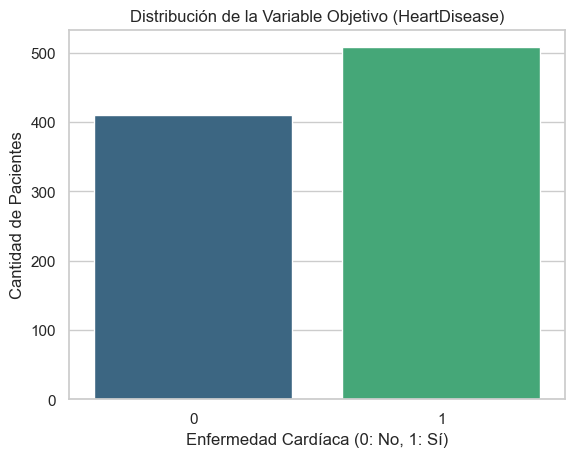

In [14]:
# Creamos el gráfico de barras para el balance de clases
sns.countplot(x='HeartDisease', data=df, palette='viridis')

# Añadimos títulos para que sea profesional
plt.title('Distribución de la Variable Objetivo (HeartDisease)')
plt.xlabel('Enfermedad Cardíaca (0: No, 1: Sí)')
plt.ylabel('Cantidad de Pacientes')

# Mostramos el gráfico
plt.show()

¿Cuáles son las características demográficas de la población? (edad, sexo)

C:\Users\gemit\AppData\Local\Temp\ipykernel_25476\1759849410.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex', data=df, palette='magma')


Sex
M    725
F    193
Name: count, dtype: int64


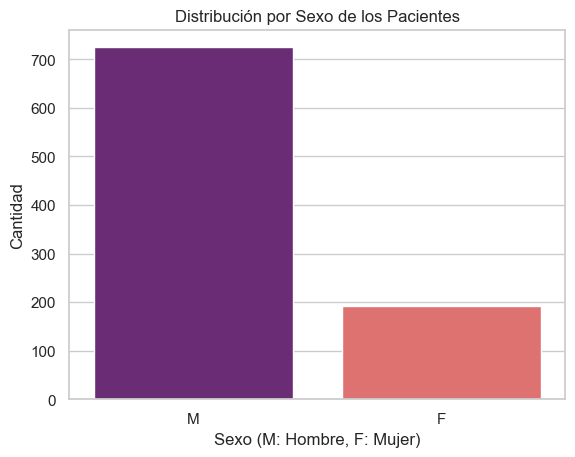

In [15]:
print(df["Sex"].value_counts())

sns.countplot(x='Sex', data=df, palette='magma')
plt.title('Distribución por Sexo de los Pacientes')
plt.xlabel('Sexo (M: Hombre, F: Mujer)')
plt.ylabel('Cantidad')
plt.show()

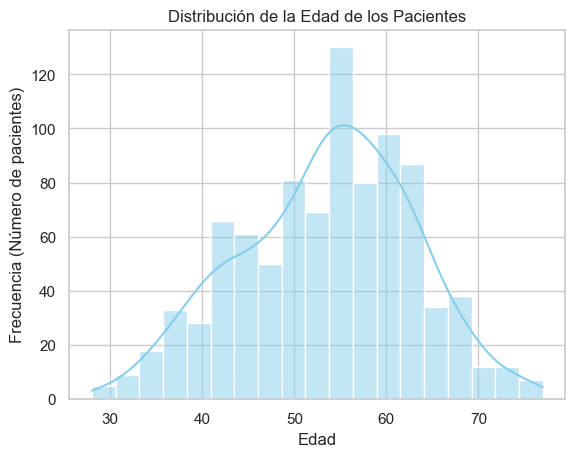

count    918.000000
mean      53.510893
std        9.432617
min       28.000000
25%       47.000000
50%       54.000000
75%       60.000000
max       77.000000
Name: Age, dtype: float64


In [16]:
# Histograma para ver la distribución de edades
sns.histplot(df['Age'], kde=True, color='skyblue')
plt.title('Distribución de la Edad de los Pacientes')
plt.xlabel('Edad')
plt.ylabel('Frecuencia (Número de pacientes)')
plt.show()

# También podemos ver la edad mínima, máxima y media rápidamente
print(df['Age'].describe())

¿Cómo se distribuye la edad y el sexo en pacientes con y sin enfermedad?

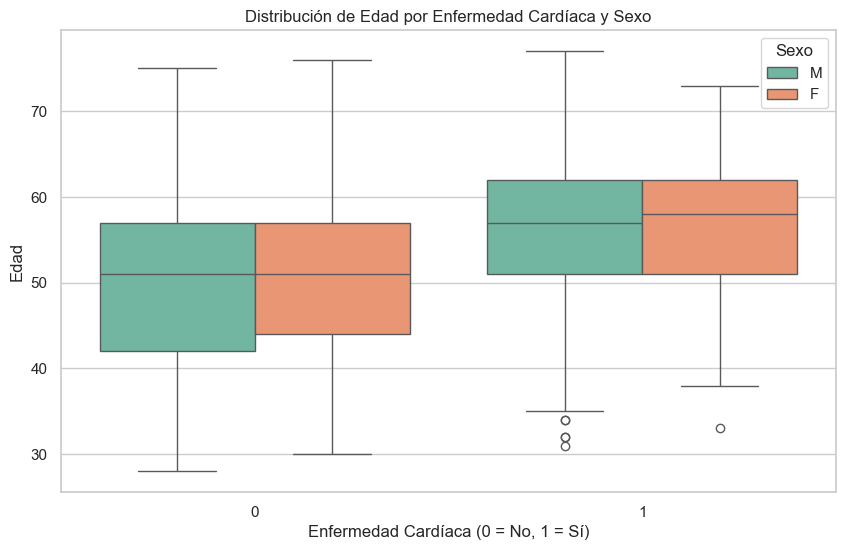

In [17]:
# Comparamos la Edad frente a la Enfermedad, diferenciando por Sexo
plt.figure(figsize=(10, 6))
sns.boxplot(x='HeartDisease', y='Age', hue='Sex', data=df, palette='Set2')

plt.title('Distribución de Edad por Enfermedad Cardíaca y Sexo')
plt.xlabel('Enfermedad Cardíaca (0 = No, 1 = Sí)')
plt.ylabel('Edad')
plt.legend(title='Sexo')
plt.show()

¿Existe diferencia en los niveles de colesterol entre ambos grupos?

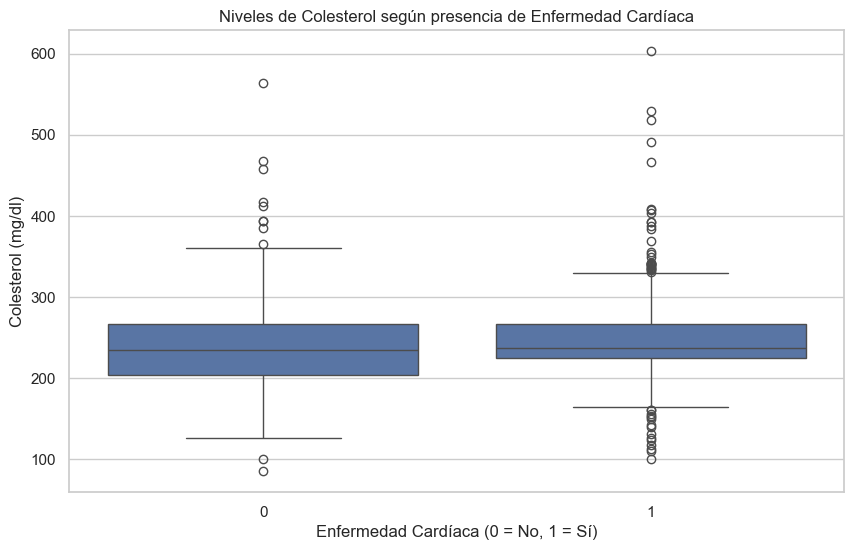

In [18]:
plt.figure(figsize=(10,6)) 

sns.boxplot(x='HeartDisease', y='Cholesterol', data=df) 

plt.title('Niveles de Colesterol según presencia de Enfermedad Cardíaca')
plt.xlabel('Enfermedad Cardíaca (0 = No, 1 = Sí)')
plt.ylabel('Colesterol (mg/dl)')
plt.show()

Tras comprobar el grafico del colesterol como influye para la enfemedad cardiaca deduzco que como en Colesterol habia valores 0 y tuvimos que poner la media no me parecen datos muy reales para mi modelo.

Miramos la frecuencia carciaca maxima frente a la enfermedad

C:\Users\gemit\AppData\Local\Temp\ipykernel_25476\3431257676.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='HeartDisease', y='MaxHR', data=df, palette='coolwarm')


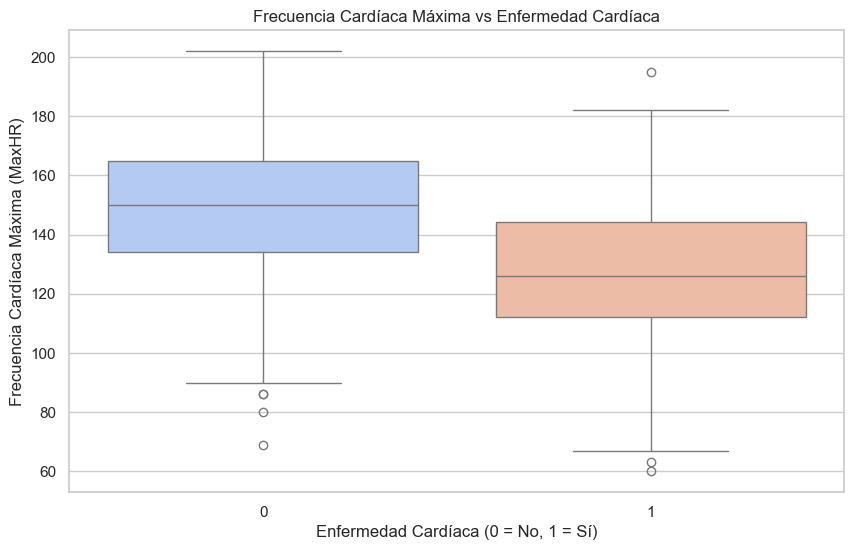

In [19]:
plt.figure(figsize=(10,6))

# Comparamos la Frecuencia Cardíaca Máxima (MaxHR) con la enfermedad
sns.boxplot(x='HeartDisease', y='MaxHR', data=df, palette='coolwarm')

plt.title('Frecuencia Cardíaca Máxima vs Enfermedad Cardíaca')
plt.xlabel('Enfermedad Cardíaca (0 = No, 1 = Sí)')
plt.ylabel('Frecuencia Cardíaca Máxima (MaxHR)')
plt.show()

Miramos la presion arterial en reposo

C:\Users\gemit\AppData\Local\Temp\ipykernel_25476\2599779010.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='HeartDisease', y='RestingBP', data=df, palette='Reds')


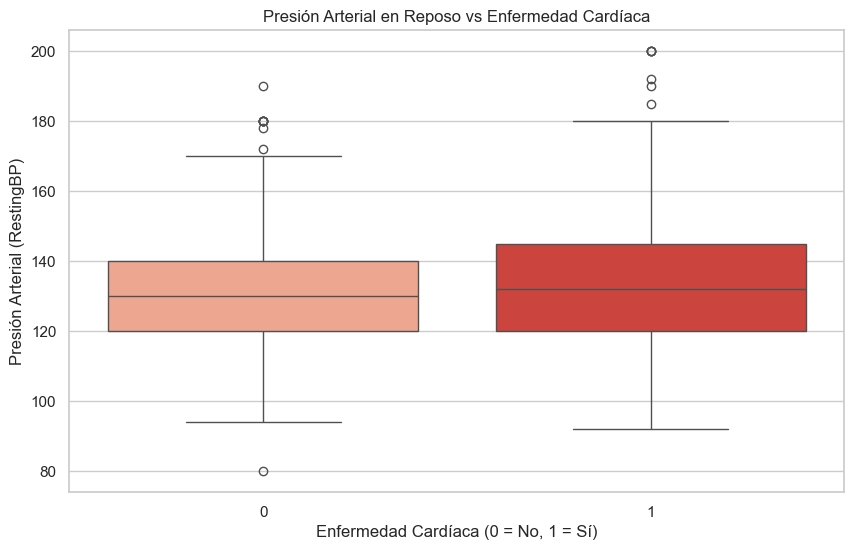

In [20]:
plt.figure(figsize=(10,6))
sns.boxplot(x='HeartDisease', y='RestingBP', data=df, palette='Reds')

plt.title('Presión Arterial en Reposo vs Enfermedad Cardíaca')
plt.xlabel('Enfermedad Cardíaca (0 = No, 1 = Sí)')
plt.ylabel('Presión Arterial (RestingBP)')
plt.show()

Transformar los datos a datos binarios

In [21]:
df["Sex"] = df["Sex"].map({"M" : 1, "F" : 0})
df['ExerciseAngina'] = df['ExerciseAngina'].map({'Y': 1, 'N': 0})
print(df[["Sex" , 'ExerciseAngina' ]].head())

   Sex  ExerciseAngina
0    1               0
1    0               0
2    1               0
3    0               1
4    1               0


In [22]:
print(df['ChestPainType'].value_counts())

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64


Transformamos la columna 'ChestPainType' con One-Hot Encoding para que sean numeros.

In [23]:
df = pd.get_dummies(df, columns=['ChestPainType'], prefix='CP', dtype=int)

# Ahora sí deberías ver 1 y 0
print(df.filter(like='CP').head())

   CP_ASY  CP_ATA  CP_NAP  CP_TA
0       0       1       0      0
1       0       0       1      0
2       0       1       0      0
3       1       0       0      0
4       0       0       1      0


In [24]:
# Verificamos las opciones de las columnas que nos faltan
print("Opciones en RestingECG:", df['RestingECG'].unique())
print("Opciones en ST_Slope:", df['ST_Slope'].unique())

Opciones en RestingECG: <ArrowStringArray>
['Normal', 'ST', 'LVH']
Length: 3, dtype: str
Opciones en ST_Slope: <ArrowStringArray>
['Up', 'Flat', 'Down']
Length: 3, dtype: str


In [25]:
df = pd.get_dummies(df, columns=['RestingECG', 'ST_Slope'], dtype=int)
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  
 1   Sex                918 non-null    int64  
 2   RestingBP          918 non-null    int64  
 3   Cholesterol        918 non-null    int64  
 4   FastingBS          918 non-null    int64  
 5   MaxHR              918 non-null    int64  
 6   ExerciseAngina     918 non-null    int64  
 7   Oldpeak            918 non-null    float64
 8   HeartDisease       918 non-null    int64  
 9   CP_ASY             918 non-null    int64  
 10  CP_ATA             918 non-null    int64  
 11  CP_NAP             918 non-null    int64  
 12  CP_TA              918 non-null    int64  
 13  RestingECG_LVH     918 non-null    int64  
 14  RestingECG_Normal  918 non-null    int64  
 15  RestingECG_ST      918 non-null    int64  
 16  ST_Slope_Down      918 non-null    in

## Análisis de relaciones entre variables

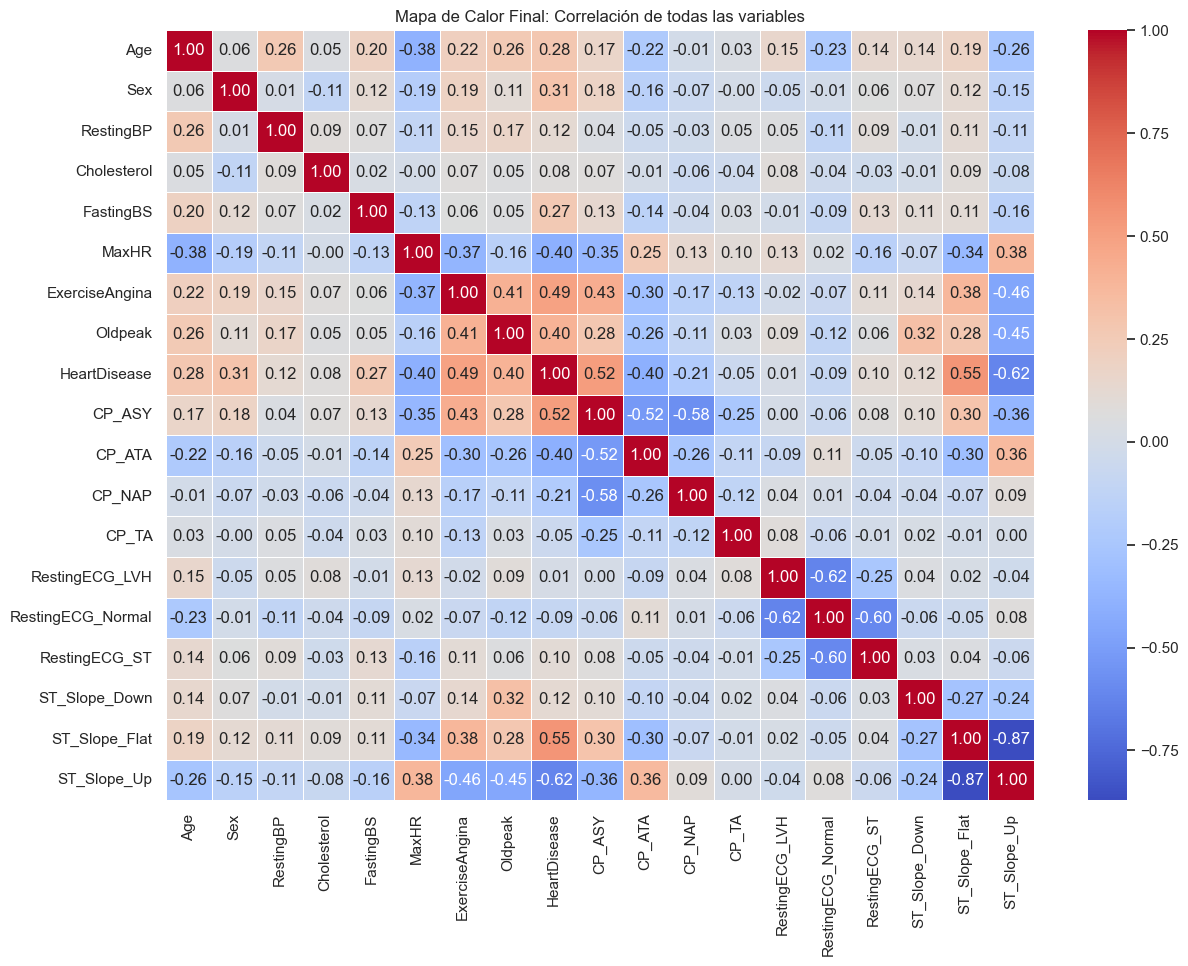

In [26]:
# Calculamos la correlación de todo el dataset procesado
plt.figure(figsize=(14, 10))
full_correlation = df.corr()

# Dibujamos el mapa de calor
sns.heatmap(full_correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor Final: Correlación de todas las variables')
plt.show()

Vamos analizar Diabetes (FastingBS), Edad (Age) y Frecuencia Máxima (MaxHR) para ver cual es su relacion entre ellas 

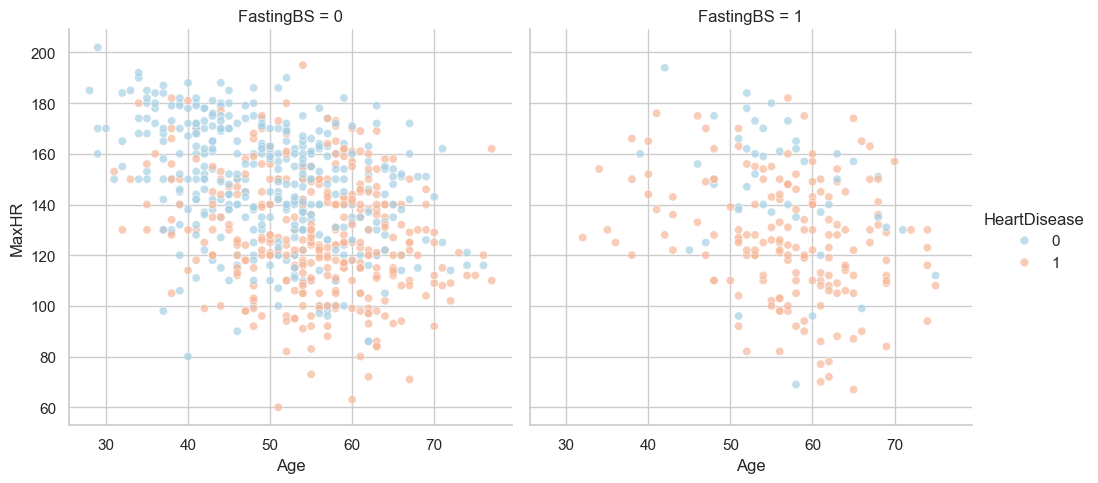

In [27]:
# Gráfico de dispersión de Edad vs MaxHR, separado por Diabetes (FastingBS)
sns.relplot(
    data=df, 
    x='Age', 
    y='MaxHR', 
    hue='HeartDisease', 
    col='FastingBS', 
    kind='scatter', 
    palette='RdBu_r',
    alpha=0.7
)

# Conclusión
La concusión que saco de mi análisis es:
* Frecuencia Cardíaca: Es un predictor clave; si es baja (cerca de 120-130), el riesgo se dispara.

* Diabetes: Aunque hay menos pacientes diabéticos, la gran mayoría de ellos presentan enfermedad cardíaca, independientemente de si son algo más jóvenes.

* ST_Slope y CP_ASY: Son las variables "estrella" del mapa de calor con mayor correlación.

Entonces estas 4 variables voy a elegir mas edad y sexo para mi modelo descarto colesterol porque le hemos imputado 172 valores de la media de colesterol y creo que no me va dar buenos resultados porque pienso que falsea los datos.

In [28]:
# Guardamos el dataset ya procesado y limpio para el modelo
df.to_csv("../data/heart_procesado_g.csv", index=False)
print("¡Archivo listo para el modelo!")

¡Archivo listo para el modelo!
